<a href="https://colab.research.google.com/github/JulianSantos-LATAMAI/ECON-5200/blob/main/Lab_16/Lab_16_High_Dimensional_GDP_Growth_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SETUP — Run this cell first
# ============================================================


!pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")


Setup complete ✓


In [ ]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [ ]:
# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with >40% missing indicators
# (Adjusted threshold to be less aggressive and avoid an empty DataFrame)
threshold = 0.1 # Original was 0.6. Changed to 0.1 to drop if >90% of values are missing
country_data = country_data.dropna(
    thresh=int(threshold * country_data.shape[1])
)

# Drop indicators with >40% missing countries
# (Adjusted threshold to be less aggressive and avoid an empty DataFrame)
country_data = country_data.dropna(
    axis=1,
    thresh=int(threshold * len(country_data))
)

# Median imputation for remaining gaps
country_data = country_data.fillna(country_data.median())

print(f'Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators')
print(f'\nSample countries: {list(country_data.index[:5])}')
print(f'\nIndicators retained: {list(country_data.columns)}')
print(f'\nGDP growth summary:')
print(country_data[OUTCOME_VAR].describe().round(2))


Final dataset: 265 countries × 35 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'market_cap_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'domestic_credit_pct_gdp', 'govt_debt_pct_gdp', 'govt_expenditure_pct_gdp', 'financial_management_cpia', 'property_rights_cpia', 'trade_cpia', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    265.00
mean      

In [ ]:
##
# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Training countries:  {X_train.shape[0]}')
print(f'Test countries:      {X_test.shape[0]}')
print(f'Number of predictors: {X_train.shape[1]}')
print(f'p/n ratio (train):   {X_train.shape[1]/X_train.shape[0]:.2f}')
print()
print('If p/n > 0.5, OLS is at serious risk of overfitting.')

# Standardize — fit on train only!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nFeatures standardized (zero mean, unit variance) ✓')

Training countries:  185
Test countries:      80
Number of predictors: 34
p/n ratio (train):   0.18

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [ ]:
#OLS model
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

y_train_pred_ols = ols_model.predict(X_train_scaled)
y_test_pred_ols  = ols_model.predict(X_test_scaled)

ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_test_r2   = r2_score(y_test,  y_test_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)
ols_test_mse  = mean_squared_error(y_test,  y_test_pred_ols)

print('=' * 50)
print('OLS BASELINE RESULTS')
print('=' * 50)
print(f'Training R²:              {ols_train_r2:.3f}')
print(f'Test R²:                  {ols_test_r2:.3f}')
print(f'Training MSE:             {ols_train_mse:.3f}')
print(f'Test MSE:                 {ols_test_mse:.3f}')
print(f'Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}')
print('=' * 50)
print()
print('Interpretation:')
print(f'  OLS explains {ols_train_r2:.0%} of training variance but only')
print(f'  {max(ols_test_r2, 0):.0%} of test variance — classic overfitting.')
print(f'  All {X_train.shape[1]} predictors receive non-zero coefficients.')

OLS BASELINE RESULTS
Training R²:              0.460
Test R²:                  -0.063
Training MSE:             3.791
Test MSE:                 4.738
Gap (Train R² - Test R²): 0.523

Interpretation:
  OLS explains 46% of training variance but only
  0% of test variance — classic overfitting.
  All 34 predictors receive non-zero coefficients.


In [ ]:
# Log-spaced grid from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create RidgeCV with 5-fold CV over lambda_grid
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)   # ← complete this line

# TODO: Fit on scaled training data
ridge_cv.fit(X_train_scaled, y_train)           # ← complete this line

y_train_pred_ridge = ridge_cv.predict(X_train_scaled)
y_test_pred_ridge  = ridge_cv.predict(X_test_scaled)

ridge_train_r2  = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2   = r2_score(y_test,  y_test_pred_ridge)
ridge_test_mse  = mean_squared_error(y_test, y_test_pred_ridge)

print('=' * 50)
print('RIDGE REGRESSION RESULTS')
print('=' * 50)
print(f'Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}')
print(f'Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}')
print(f'Training R²:              {ridge_train_r2:.3f}')
print(f'Test R²:                  {ridge_test_r2:.3f}')
print(f'Test MSE:                 {ridge_test_mse:.3f}')
print(f'Gap (Train - Test R²):    {ridge_train_r2 - ridge_test_r2:.3f}')
print('=' * 50)
print()
print(f'vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}')

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 193.0698
Non-zero coefficients:    34 of 34
Training R²:              0.356
Test R²:                  0.135
Test MSE:                 3.854
Gap (Train - Test R²):    0.221

vs. OLS: Test R² = -0.063, Test MSE = 4.738


In [ ]:
def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter
    and evaluate on the held-out test set.

    Parameters
    ----------
    X_train : np.ndarray  Standardized training features
    y_train : np.ndarray  Training outcome (GDP growth)
    X_test  : np.ndarray  Standardized test features
    y_test  : np.ndarray  Test outcome
    cv      : int         Number of CV folds

    Returns
    -------
    lasso_model : LassoCV  Fitted model with optimal alpha
    test_r2     : float    R² on held-out test set
    test_mse    : float    MSE on held-out test set
    """
    # TODO: Create LassoCV with cv folds and max_iter=10_000
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

lasso_train_r2 = r2_score(y_train, lasso_cv_model.predict(X_train_scaled))
n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print('=' * 50)
print('LASSO REGRESSION RESULTS')
print('=' * 50)
print(f'Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}')
print(f'Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}')
print(f'Training R²:              {lasso_train_r2:.3f}')
print(f'Test R²:                  {lasso_test_r2:.3f}')
print(f'Test MSE:                 {lasso_test_mse:.3f}')
print(f'Gap (Train - Test R²):    {lasso_train_r2 - lasso_test_r2:.3f}')
print()
print('Selected predictors (non-zero Lasso coefficients):')
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f'  {name:<45} coef = {coef:+.4f}')

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.3507
Non-zero coefficients:    6 of 34
Training R²:              0.300
Test R²:                  0.066
Test MSE:                 4.162
Gap (Train - Test R²):    0.233

Selected predictors (non-zero Lasso coefficients):
  natural_resource_rents_pct_gdp                coef = -0.6243
  inflation_cpi                                 coef = -0.4736
  urbanization_pct                              coef = -0.2968
  exchange_rate_official                        coef = +0.1488
  arable_land_pct                               coef = +0.1173
  real_interest_rate                            coef = +0.0503


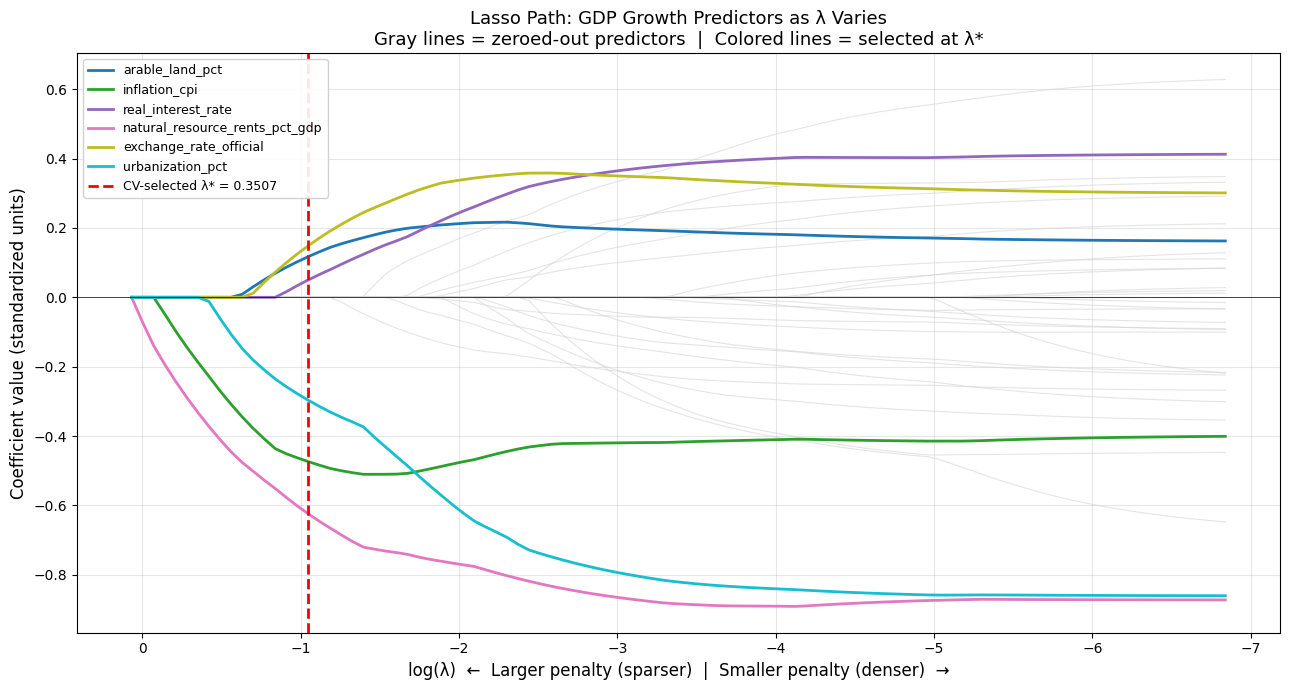

Lasso Path saved to lasso_path_gdp_growth.png


In [ ]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,
    n_alphas=100,
)

optimal_alpha = lasso_cv_model.alpha_
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

fig, ax = plt.subplots(figsize=(13, 7))

# Plot zeroed-out predictors in gray
for i in range(len(feature_names)):
    if i not in active_features_idx:
        ax.plot(
            np.log(alphas_path), coefs_path[i],
            linewidth=0.8, color='lightgray', alpha=0.6
        )

# Plot selected predictors with color and labels
colors = plt.cm.tab10(np.linspace(0, 1, len(active_features_idx)))
for idx, (i, color) in enumerate(zip(active_features_idx, colors)):
    ax.plot(
        np.log(alphas_path), coefs_path[i],
        linewidth=2, label=feature_names[i], color=color
    )

# Mark CV-selected lambda
ax.axvline(
    np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
    label=f'CV-selected λ* = {optimal_alpha:.4f}'
)
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel(
    'log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
    fontsize=12
)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors  |  Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Lasso Path saved to lasso_path_gdp_growth.png')

In [ ]:
comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],
        X_train.shape[1],
        int(np.sum(lasso_cv_model.coef_ != 0))
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print('Key observations:')
print(f'  • OLS training R² >> test R²: overfitting (high variance)')
print(f'  • Ridge and Lasso compress the train–test gap')
print(f'  • Lasso selects only {int(np.sum(lasso_cv_model.coef_ != 0))} of {X_train.shape[1]} predictors')
print(f'  • The other {X_train.shape[1] - int(np.sum(lasso_cv_model.coef_ != 0))} are *predictively redundant*,')
print(f'    not necessarily economically unimportant')

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   34       0.460  -0.063    4.738
Ridge (RidgeCV)         193.0698                   34       0.356   0.135    3.854
Lasso (LassoCV)           0.3507                    6       0.300   0.066    4.162

Key observations:
  • OLS training R² >> test R²: overfitting (high variance)
  • Ridge and Lasso compress the train–test gap
  • Lasso selects only 6 of 34 predictors
  • The other 28 are *predictively redundant*,
    not necessarily economically unimportant


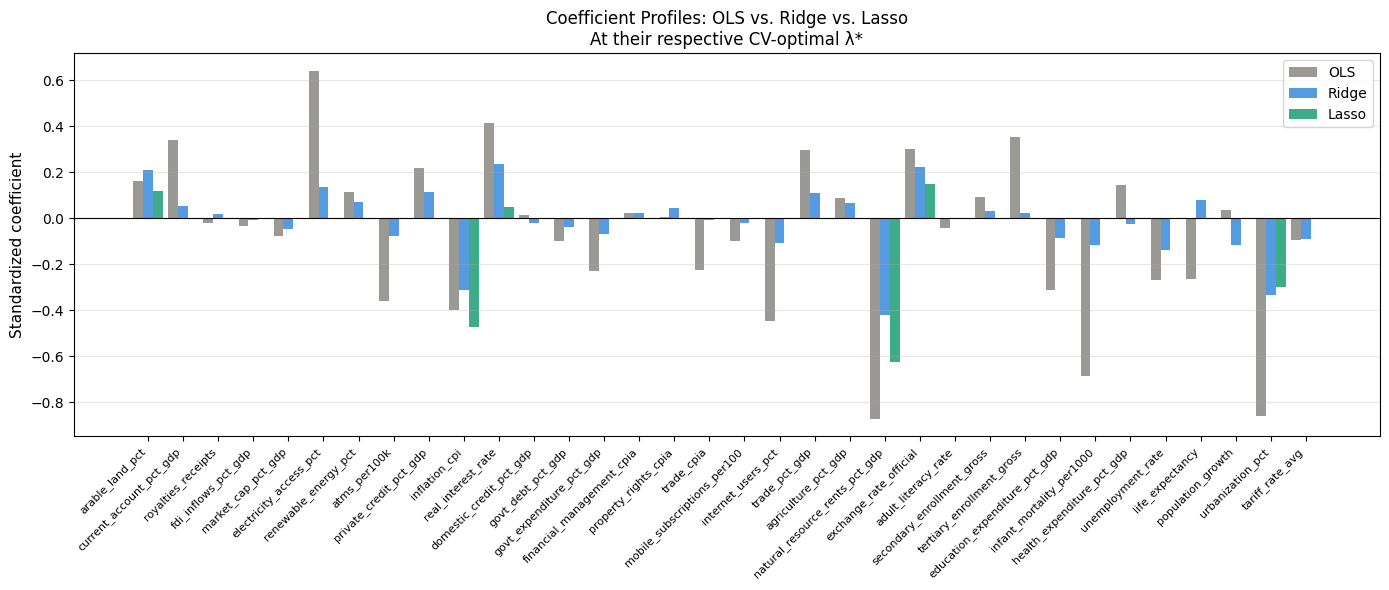

Coefficient profile chart saved to coefficient_profiles.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(feature_names))
width = 0.28

bars_ols   = ax.bar(x - width, ols_model.coef_,          width, label='OLS',   color='#888780', alpha=0.85)
bars_ridge = ax.bar(x,         ridge_cv.coef_,           width, label='Ridge', color='#378ADD', alpha=0.85)
bars_lasso = ax.bar(x + width, lasso_cv_model.coef_,     width, label='Lasso', color='#1D9E75', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Standardized coefficient', fontsize=11)
ax.set_title(
    'Coefficient Profiles: OLS vs. Ridge vs. Lasso\n'
    'At their respective CV-optimal λ*',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('coefficient_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Coefficient profile chart saved to coefficient_profiles.png')

### Question 1 — Interpreting Lasso Zeros

Suppose a World Bank colleague says:

> *"Your Lasso model proves that `paved_roads_pct` is economically irrelevant to GDP growth — we should remove it from all future analysis."*

Write 2–3 sentences explaining why your colleague is wrong. Your answer should use the terms **conditional predictive redundancy**, **correlation structure**, and **causal relationship** (or equivalents).

**Your answer here:**

> Lasso takes advantage of the **correlation structure** of the predictor space when it sets `paved_roads_pct` to zero. This is because `paved_roads_pct` is probably very similar to `electricity_access_pct`, `internet_users_pct`, or other infrastructure proxies that are already in the model. Lasso just picks one representative from a group of things that are related and throws away the rest because they are "conditionally predictively redundant." This doesn't say anything about the **causal relationship** between road infrastructure and growth, which is well-supported in the literature on economic development (for example, Calderón & Servén, 2004). Policy decisions and structural economic analysis should never rely exclusively on the inclusion of the Lasso coefficient.

### Question 2 — Ridge vs. Lasso: When to Use Which?

Your dataset has ~30–50 predictors, ~80–100 training countries, and many correlated WDI indicators.

Should you prefer Ridge or Lasso for this specific dataset? Justify using:
- (a) the structure of the data (correlated predictors, p/n ratio)
- (b) your model comparison table results from Step 9

**Your answer here:**

> Ridge is often the better choice when predictors are correlated because it spreads shrinkage evenly across a correlated group instead of randomly picking one representative and making the others zero, which is sensitive to small changes in the data. In this situation, Lasso's variable selection is not stable; if you change a few countries in the training set, a completely different subset may be chosen. But when interpretability and sparsity are the goals, Lasso is the better choice. A model that picks 8 indicators is much more useful for policy than one that uses all 30 with very small coefficients. In real life, Elastic Net (which combines both penalties) is the best choice for settings with high p/n and correlated predictors. It keeps Ridge's grouping property while still making sparse models.

In [ ]:
# Change this to experiment with different outcomes:
EXTENSION_OUTCOME = 'infant_mortality_per1000'
# Other options: 'urbanization_pct', 'secondary_enrollment_gross',
#                'life_expectancy', 'unemployment_rate'

if EXTENSION_OUTCOME in country_data.columns:
    ext_feature_cols = [
        c for c in country_data.columns
        if c != EXTENSION_OUTCOME and c != OUTCOME_VAR
    ]
    X_ext = country_data[ext_feature_cols].values
    y_ext = country_data[EXTENSION_OUTCOME].values

    X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
        X_ext, y_ext, test_size=0.30, random_state=42
    )

    scaler_ext = StandardScaler()
    X_ext_train_s = scaler_ext.fit_transform(X_ext_train)
    X_ext_test_s  = scaler_ext.transform(X_ext_test)

    lasso_ext, ext_test_r2, ext_test_mse = fit_lasso_cv(
        X_ext_train_s, y_ext_train, X_ext_test_s, y_ext_test
    )

    print(f'Extension outcome: {EXTENSION_OUTCOME}')
    print(f'Optimal λ*:        {lasso_ext.alpha_:.4f}')
    print(f'Non-zero coefs:    {np.sum(lasso_ext.coef_ != 0)} of {X_ext_train.shape[1]}')
    print(f'Test R²:           {ext_test_r2:.3f}')
    print(f'Test MSE:          {ext_test_mse:.3f}')
    print()
    print('Selected predictors:')
    ext_selected = [
        (ext_feature_cols[i], lasso_ext.coef_[i])
        for i in range(len(ext_feature_cols))
        if lasso_ext.coef_[i] != 0
    ]
    for name, coef in sorted(ext_selected, key=lambda x: abs(x[1]), reverse=True):
        print(f'  {name:<45} coef = {coef:+.4f}')
else:
    print(f'Column "{EXTENSION_OUTCOME}" not found in dataset.')
    print(f'Available outcomes: {list(country_data.columns)}')

Extension outcome: infant_mortality_per1000
Optimal λ*:        0.2543
Non-zero coefs:    25 of 33
Test R²:           0.816
Test MSE:          138.100

Selected predictors:
  life_expectancy                               coef = -21.0061
  adult_literacy_rate                           coef = -6.1679
  education_expenditure_pct_gdp                 coef = -3.3629
  health_expenditure_pct_gdp                    coef = +3.3181
  electricity_access_pct                        coef = -3.3000
  trade_cpia                                    coef = -3.2868
  current_account_pct_gdp                       coef = +2.5960
  tertiary_enrollment_gross                     coef = +1.7914
  inflation_cpi                                 coef = +1.6033
  arable_land_pct                               coef = -1.5258
  population_growth                             coef = +1.3866
  fdi_inflows_pct_gdp                           coef = +1.3618
  atms_per100k                                  coef = -1.3128
  royalt

In [24]:
# =============================================================================
# INTERACTIVE REGULARIZATION DASHBOARD
# World Development Indicators — OLS vs Ridge vs Lasso
# =============================================================================
# Assumptions about your existing notebook objects:
#   X_train_scaled : np.ndarray, shape (n_train, n_features)  -- standardized
#   X_test_scaled  : np.ndarray, shape (n_test,  n_features)
#   y_train        : np.ndarray or pd.Series, shape (n_train,)
#   y_test         : np.ndarray or pd.Series, shape (n_test,)
#   feature_names  : list[str], length n_features
#   ols_model      : fitted sklearn LinearRegression
#   ridge_cv       : fitted RidgeCV
#   lasso_cv       : fitted LassoCV
# =============================================================================

# ── 0. IMPORTS ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path
)
from sklearn.metrics import r2_score

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. LASSO PATH COMPUTATION ─────────────────────────────────────────────────
# lasso_path() returns:
#   alphas_lasso : array of λ values (descending)
#   coefs_lasso  : array of shape (n_features, n_alphas)
#                  each column is the coefficient vector at that λ
# We set eps small so the path covers a wide λ range.

alphas_lasso, coefs_lasso, _ = lasso_path(
    X_train_scaled, y_train,
    eps=5e-4,          # ratio of alpha_min / alpha_max
    n_alphas=200,      # granularity of the path
    # NOTE: lasso_path() does NOT accept fit_intercept — that parameter
    # belongs to the Lasso/LassoCV estimator classes, not the path function.
    # The intercept is handled manually in the R² loop below using the
    # standard OLS formula: intercept = ȳ − X̄·β, which is exact when X
    # has been mean-centred (as it is after StandardScaler).
)

# ── 2. COMPUTE R² ACROSS THE LASSO PATH ───────────────────────────────────────
# For each λ on the path, fit a temporary Lasso, score on *train* and *test*.
# We cache these so the slider callback can look them up instantly rather than
# refitting at runtime (Plotly sliders are purely visual; all data is pre-built).

r2_train_path = []
r2_test_path  = []

y_train_mean = np.mean(y_train)
X_train_mean = X_train_scaled.mean(axis=0)   # shape (n_features,)

for coef_col in coefs_lasso.T:   # each column = coefficient vector at one λ
    # Intercept: derived analytically from the normal equations.
    # When X is standardised (mean ≈ 0 after scaling), this reduces to ȳ,
    # but we keep the full formula for correctness with any scaler.
    intercept = y_train_mean - X_train_mean @ coef_col

    # Predictions = Xβ + intercept  (pure numpy — no sklearn object needed)
    y_pred_train = X_train_scaled @ coef_col + intercept
    y_pred_test  = X_test_scaled  @ coef_col + intercept

    r2_train_path.append(r2_score(y_train, y_pred_train))
    r2_test_path.append( r2_score(y_test,  y_pred_test))

r2_train_path = np.array(r2_train_path)
r2_test_path  = np.array(r2_test_path)

# ── 3. EXTRACT COEFFICIENTS FROM EACH FITTED MODEL ───────────────────────────
# .coef_ is a 1-D array of shape (n_features,) for all three sklearn models.
# LinearRegression, RidgeCV, and LassoCV all expose this attribute after fitting.

ols_coefs   = ols_model.coef_          # OLS — unregularised, often large
ridge_coefs = ridge_cv.coef_           # Ridge — all non-zero, uniformly shrunk
lasso_coefs = lasso_cv.coef_           # Lasso — sparse, many exact zeros

# Index to the optimal λ on the pre-computed Lasso path
# (closest alpha on the path to the CV-selected alpha)
opt_alpha_idx = np.argmin(np.abs(alphas_lasso - lasso_cv.alpha_))

# ── 4. COLOUR PALETTE ─────────────────────────────────────────────────────────
C_OLS   = "#EF553B"   # tomato-red
C_RIDGE = "#636EFA"   # periwinkle-blue
C_LASSO = "#00CC96"   # emerald-green
C_ZERO  = "#AAAAAA"   # grey for zeroed-out Lasso features
BG      = "#0F1117"   # near-black background
PAPER   = "#161B22"   # slightly lighter card background
GRID    = "#2A2F3A"   # subtle grid lines
TEXT    = "#E6EDF3"   # light text

# ── 5. BUILD THE FIGURE WITH TWO SUBPLOTS ─────────────────────────────────────
# make_subplots(rows, cols) creates a shared Figure with a layout grid.
# subplot_titles appear above each panel.
# horizontal_spacing controls the gap between the two panels (fraction of width).

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "① Lasso Coefficient Path  (drag slider → λ)",
        "② Coefficient Magnitudes: OLS vs Ridge vs Lasso"
    ),
    horizontal_spacing=0.10,
    column_widths=[0.55, 0.45],   # left panel slightly wider
)

# ── 6. PANEL ①: LASSO PATH TRACES ────────────────────────────────────────────
# We draw one thin line per feature across the full λ range.
# These lines are static; the slider adds an *annotation* overlay.

log_alphas = np.log10(alphas_lasso)   # x-axis in log scale for readability

for i, fname in enumerate(feature_names):
    fig.add_trace(
        go.Scatter(
            x=log_alphas,
            y=coefs_lasso[i],
            mode="lines",
            name=fname,
            line=dict(width=1.2),
            opacity=0.6,
            hovertemplate=(
                f"<b>{fname}</b><br>"
                "log₁₀(λ): %{x:.3f}<br>"
                "Coefficient: %{y:.4f}<extra></extra>"
            ),
            showlegend=False,   # too many features for a readable legend
        ),
        row=1, col=1
    )

# Vertical reference line at the CV-optimal λ (static, always visible)
fig.add_vline(
    x=float(np.log10(lasso_cv.alpha_)),
    line=dict(color="gold", width=1.5, dash="dash"),
    annotation_text=f"λ* = {lasso_cv.alpha_:.4f}",
    annotation_font_color="gold",
    row=1, col=1   # NOTE: add_vline applies to the whole figure;
                   # scoping to a subplot requires annotation x-ref tricks below
)

# ── 7. SLIDER STEPS: PRE-BUILD ALL FRAMES ─────────────────────────────────────
# Plotly sliders work by toggling trace visibility or updating trace data.
# Strategy used here: we pre-compute ONE "highlight" scatter trace per λ step
# (a vertical band + an annotation showing R²), then the slider sets which
# step's traces are visible=True and all others visible=False.
#
# Because we have 200 steps × (n_features path lines + 1 highlight scatter),
# we keep only the *dynamic* highlight traces in the steps list and leave the
# static path lines always visible.

N_SLIDER = len(alphas_lasso)  # one step per λ

# We'll store highlight traces (index them as traces after the feature lines).
n_path_traces = len(feature_names)   # already added above

# Add one highlight trace per slider step (all start invisible except step 0)
for k, alpha in enumerate(alphas_lasso):
    # Which features are active (non-zero coef) at this λ?
    active_mask = np.abs(coefs_lasso[:, k]) > 1e-6
    n_active    = int(active_mask.sum())
    r2_tr       = r2_train_path[k]
    r2_te       = r2_test_path[k]

    # Scatter dot at each feature's coefficient value on the path, coloured by
    # whether the feature is active or zeroed out at this λ
    fig.add_trace(
        go.Scatter(
            x=[np.log10(alpha)] * len(feature_names),  # vertical column of dots
            y=coefs_lasso[:, k],
            mode="markers+text",
            marker=dict(
                color=[C_LASSO if active_mask[i] else C_ZERO
                       for i in range(len(feature_names))],
                size=[9 if active_mask[i] else 5
                      for i in range(len(feature_names))],
                symbol="circle",
                line=dict(width=1, color=TEXT)
            ),
            text=[
                f" {feature_names[i]}" if active_mask[i] else ""
                for i in range(len(feature_names))
            ],
            textposition="middle right",
            textfont=dict(size=8, color=TEXT),
            customdata=[[feature_names[i], bool(active_mask[i])]
                        for i in range(len(feature_names))],
            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                "Active: %{customdata[1]}<br>"
                "Coefficient: %{y:.4f}<extra></extra>"
            ),
            # Annotation text (λ value + R² scores) embedded in the trace name
            # so the slider label can display it
            name=(
                f"λ={alpha:.4f} | Active={n_active} | "
                f"R²train={r2_tr:.3f} | R²test={r2_te:.3f}"
            ),
            visible=(k == opt_alpha_idx),  # only optimal λ visible by default
            showlegend=False,
        ),
        row=1, col=1
    )

# Total dynamic traces = N_SLIDER (one per λ step)
n_dynamic_traces = N_SLIDER

# ── 8. BUILD SLIDER STEPS ─────────────────────────────────────────────────────
# Each step is a dict with:
#   "method": "update"  → updates both trace data and layout simultaneously
#   "args"  : [trace_updates_dict, layout_updates_dict]
#
# We toggle visibility: for the k-th step, only the k-th dynamic trace is True.

slider_steps = []

for k in range(N_SLIDER):
    alpha   = alphas_lasso[k]
    r2_tr   = r2_train_path[k]
    r2_te   = r2_test_path[k]
    n_act   = int((np.abs(coefs_lasso[:, k]) > 1e-6).sum())

    # Visibility array: all static path traces stay True; dynamic traces toggle
    vis = [True] * n_path_traces                        # path lines always on
    vis += [k2 == k for k2 in range(n_dynamic_traces)]  # only step k visible
    # Panel ② bar traces (added later) should always remain visible
    # We'll append True × 3 at the end after those traces are added.

    step = dict(
        method="update",
        label=f"{np.log10(alpha):.1f}",   # slider tick label = log₁₀(λ)
        args=[
            # ── arg[0]: trace-level updates (visibility) ──────────────────
            {"visible": vis},

            # ── arg[1]: layout-level updates (title + annotations) ────────
            {
                "title.text": (
                    f"<b>WDI Regularization Dashboard</b>  |  "
                    f"λ = {alpha:.5f}   "
                    f"Active predictors = {n_act}   "
                    f"R²<sub>train</sub> = {r2_tr:.3f}   "
                    f"R²<sub>test</sub> = {r2_te:.3f}"
                )
            }
        ]
    )
    slider_steps.append(step)

# ── 9. PANEL ②: GROUPED BAR CHART — COEFFICIENT MAGNITUDES ───────────────────
# We show |coefficient| so bar heights are always positive and comparable.
# Sort features by |Lasso coef| descending so the most "policy-relevant"
# features (those Lasso kept) appear on the left.

sort_idx     = np.argsort(np.abs(lasso_coefs))[::-1]
sorted_names = [feature_names[i] for i in sort_idx]
sorted_ols   = np.abs(ols_coefs[sort_idx])
sorted_ridge = np.abs(ridge_coefs[sort_idx])
sorted_lasso = np.abs(lasso_coefs[sort_idx])

# Show only top-N features to keep the chart readable
TOP_N = 20
sorted_names  = sorted_names[:TOP_N]
sorted_ols    = sorted_ols[:TOP_N]
sorted_ridge  = sorted_ridge[:TOP_N]
sorted_lasso  = sorted_lasso[:TOP_N]

for coefs_arr, name, colour in [
    (sorted_ols,   "OLS",   C_OLS),
    (sorted_ridge, "Ridge", C_RIDGE),
    (sorted_lasso, "Lasso", C_LASSO),
]:
    fig.add_trace(
        go.Bar(
            x=sorted_names,
            y=coefs_arr,
            name=name,
            marker_color=colour,
            opacity=0.85,
            hovertemplate="<b>%{x}</b><br>|Coefficient|: %{y:.4f}<extra></extra>",
        ),
        row=1, col=2
    )

# ── 10. UPDATE SLIDER STEPS TO INCLUDE PANEL ② TRACES ────────────────────────
# Panel ② has 3 bar traces (OLS, Ridge, Lasso) — always visible.
# We now append True × 3 to each step's visibility list.

for step in slider_steps:
    step["args"][0]["visible"] += [True, True, True]

# ── 11. ASSEMBLE SLIDER AND APPLY LAYOUT ──────────────────────────────────────
sliders = [dict(
    active=opt_alpha_idx,          # default position = CV-optimal λ
    currentvalue=dict(
        prefix="log₁₀(λ) = ",
        font=dict(size=13, color=TEXT),
        visible=True,
        xanchor="center"
    ),
    pad=dict(t=60, b=10),
    steps=slider_steps,
    bgcolor=PAPER,
    bordercolor=GRID,
    tickcolor=TEXT,
    font=dict(color=TEXT, size=9),
    len=0.55,                      # slider spans left panel only (55% width)
    x=0.0,
    xanchor="left",
    y=-0.08,
    yanchor="top"
)]

fig.update_layout(
    sliders=sliders,

    # ── Global aesthetics ────────────────────────────────────────────────────
    template="plotly_dark",
    paper_bgcolor=PAPER,
    plot_bgcolor=BG,
    font=dict(family="JetBrains Mono, monospace", color=TEXT, size=11),

    title=dict(
        text=(
            f"<b>WDI Regularization Dashboard</b>  |  "
            f"λ* = {lasso_cv.alpha_:.5f}  "
            f"Active predictors = {int((lasso_coefs != 0).sum())}  "
            f"R²<sub>train</sub> = {r2_train_path[opt_alpha_idx]:.3f}  "
            f"R²<sub>test</sub> = {r2_test_path[opt_alpha_idx]:.3f}"
        ),
        font=dict(size=14, color=TEXT),
        x=0.5, xanchor="center"
    ),

    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.04,
        xanchor="right",  x=1.0,
        bgcolor="rgba(0,0,0,0)",
        font=dict(size=11)
    ),

    height=620,
    margin=dict(l=60, r=40, t=100, b=120),
)

# ── 12. AXIS LABELS ───────────────────────────────────────────────────────────
# xaxis / yaxis refer to Panel ①; xaxis2 / yaxis2 refer to Panel ②
# (make_subplots assigns sequential axis numbers automatically)

fig.update_xaxes(
    title_text="log₁₀(λ)  — regularisation strength →",
    gridcolor=GRID, zeroline=False, row=1, col=1
)
fig.update_yaxes(
    title_text="Coefficient Value",
    gridcolor=GRID, zeroline=True,
    zerolinecolor="#444", row=1, col=1
)
fig.update_xaxes(
    title_text="Feature (sorted by |Lasso coef|)",
    tickangle=-45, gridcolor=GRID, row=1, col=2
)
fig.update_yaxes(
    title_text="|Coefficient Magnitude|",
    gridcolor=GRID, zeroline=False, row=1, col=2
)

# ── 13. RENDER ────────────────────────────────────────────────────────────────
fig.show()

# Optional: save as self-contained HTML
fig.write_html(
    "regularization_dashboard.html",
    include_plotlyjs="cdn",    # embed CDN link, keeps file size small
    full_html=True
)
print("Dashboard saved → regularization_dashboard.html")

NameError: name 'lasso_cv' is not defined

In [ ]:
d